In [40]:
import pandas as pd

# ============================================
# 1. 원본 데이터 불러오기
# ============================================

df = pd.read_excel(
    "환경모델 학습용 데이터.xlsx"
)


# ============================================
# 2. 12개 채널 출력전압 / 출력전류 컬럼
# ============================================

outvolt_cols = [
    f"{ch}-OutVolt"
    for ch in range(1, 13)
]

outcurr_cols = [
    f"{ch}-OutCurr"
    for ch in range(1, 13)
]


# ============================================
# 3. 가상의 정류기 출력전압
#    → 12채널 출력전압 평균
# ============================================

df["Rectifier_Voltage"] = (
    df[outvolt_cols].mean(axis=1)
)


# ============================================
# 4. 가상의 정류기 출력전류
#    → 12채널 출력전류 합계
# ============================================

df["Rectifier_Current"] = (
    df[outcurr_cols].sum(axis=1)
)


# ============================================
# 5. 환경모델에 사용할 핵심 데이터 확인
# ============================================

print(
    df[
        [
            "DateTime",
            "Rectifier_Voltage",
            "Rectifier_Current",
            "TB1-Volt"
        ]
    ].head(20)
)


              DateTime  Rectifier_Voltage  Rectifier_Current  TB1-Volt
0  2026-08-01 00:00:29          43.739167               5.94     -1640
1  2026-08-01 00:10:29          43.790833               5.92     -1641
2  2026-08-01 00:20:29          43.515000               5.93     -1639
3  2026-08-01 00:30:29          43.728333               5.96     -1634
4  2026-08-01 00:40:29          43.569167               5.95     -1633
5  2026-08-01 00:50:29          43.565000               5.94     -1637
6  2026-08-01 01:00:29          43.426667               5.97     -1633
7  2026-08-01 01:10:29          43.470833               5.94     -1628
8  2026-08-01 01:20:29          43.700833               5.94     -1631
9  2026-08-01 01:30:29          43.720000               5.97     -1633
10 2026-08-01 01:40:29          43.455833               5.84     -1627
11 2026-08-01 01:50:29          43.752500               5.98     -1634
12 2026-08-01 02:00:30          43.527500               5.94     -1632
13 202

#### 진행한 작업
- 정류기 추정 전압 = 12개 채널의 평균전압 
- 정류기 추정 전류 = 12개 채널의 합산
- 새로운 컬럼 생성

#### 진행한 이유
- 필요한 데이터 컬럼을 새로 만들기 위해 

In [41]:
# ============================================
# DateTime 정렬 및 10분 간격 확인
# ============================================

# 혹시 문자열로 읽혔을 경우를 대비해 datetime으로 변환
df["DateTime"] = pd.to_datetime(df["DateTime"])

# 시간 순서대로 정렬
df = df.sort_values("DateTime").reset_index(drop=True)

# 현재 행과 바로 이전 행의 시간 차이 계산
df["Time_Diff"] = df["DateTime"].diff()


# ============================================
# 전체 시간 간격 분포 확인
# ============================================

print("[시간 간격별 개수]")
print(
    df["Time_Diff"]
    .value_counts()
    .sort_index()
)


# ============================================
# 10분에서 벗어난 구간 확인
#
# 초 단위 기록 오차를 고려해서
# 9분 30초 ~ 10분 30초를 정상으로 판단
# ============================================

abnormal_time = df[
    df["Time_Diff"].notna()
    &
    (
        (df["Time_Diff"] < pd.Timedelta(minutes=9, seconds=30))
        |
        (df["Time_Diff"] > pd.Timedelta(minutes=10, seconds=30))
    )
]

print("\n[10분 간격에서 벗어난 구간 수]")
print(len(abnormal_time))

print("\n[10분 간격에서 벗어난 구간]")
print(
    abnormal_time[
        [
            "DateTime",
            "Time_Diff"
        ]
    ].to_string(index=False)
)

[시간 간격별 개수]
Time_Diff
0 days 00:09:28       2
0 days 00:09:43       1
0 days 00:09:46       1
0 days 00:09:57       1
0 days 00:09:58       2
0 days 00:09:59     531
0 days 00:10:00    3061
0 days 00:10:01     565
0 days 00:10:02       2
0 days 00:10:13       1
0 days 00:10:32       1
0 days 00:19:58       1
0 days 00:19:59       4
0 days 00:20:00      28
0 days 00:20:01       9
0 days 00:20:17       1
0 days 00:20:32       1
0 days 00:30:00       1
0 days 00:40:01       1
0 days 01:10:00       1
0 days 05:20:01       1
Name: count, dtype: int64

[10분 간격에서 벗어난 구간 수]
51

[10분 간격에서 벗어난 구간]
           DateTime       Time_Diff
2026-08-01 13:10:29 0 days 00:20:00
2026-08-02 07:20:31 0 days 00:20:01
2026-08-02 21:10:32 0 days 00:20:00
2026-08-03 19:00:33 0 days 00:20:00
2026-08-04 06:10:34 0 days 00:20:00
2026-08-04 09:00:34 0 days 00:20:01
2026-08-04 13:10:34 0 days 00:20:00
2026-08-05 01:40:35 0 days 00:20:00
2026-08-05 03:20:35 0 days 00:20:00
2026-08-05 10:20:36 0 days 00:20:01
2026-08-0

#### 진행한 작업
- 시간간격 확인(정확히 10분간격인가?)
- 시간간격별 데이터 분포도 확인

#### 진행한 이유
- 시계열 데이터를 만들기위해 적합한가?
- 전압과 전류값 변화에 따라 10분뒤 어떻게 변하는지?

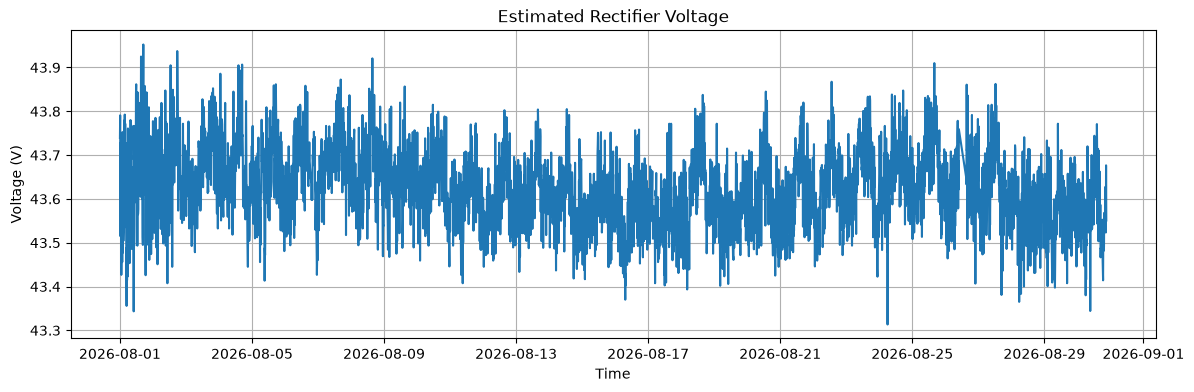

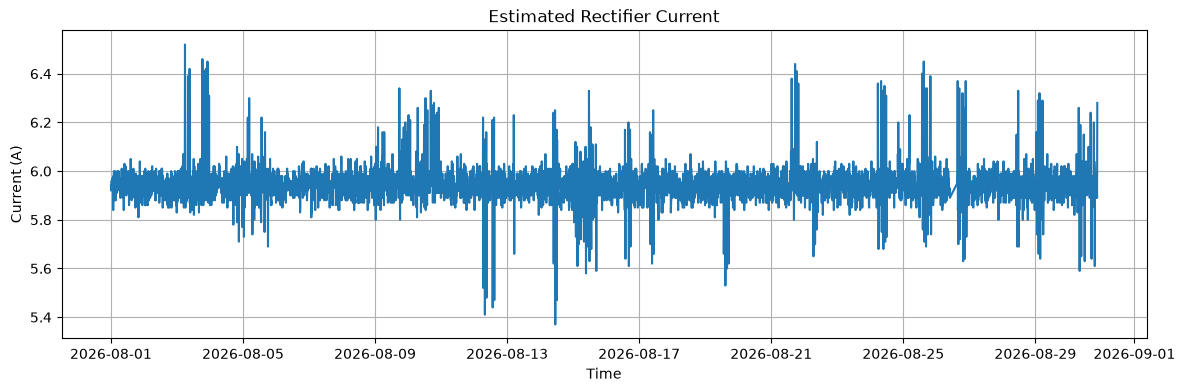

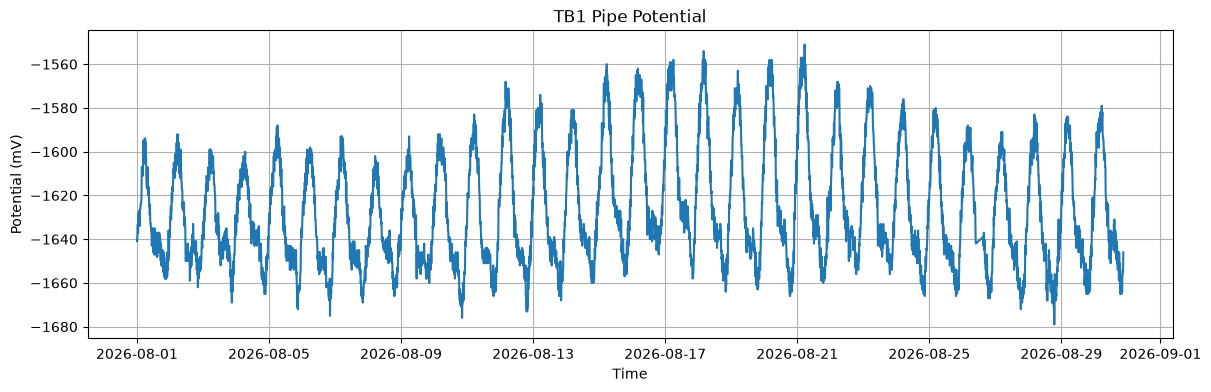

In [42]:
import matplotlib.pyplot as plt


# ============================================
# 1. 추정 정류기 출력전압 그래프
# ============================================

plt.figure(figsize=(14, 4))

plt.plot(
    df["DateTime"],
    df["Rectifier_Voltage"]
)

plt.title("Estimated Rectifier Voltage")
plt.xlabel("Time")
plt.ylabel("Voltage (V)")
plt.grid(True)

plt.show()


# ============================================
# 2. 추정 정류기 전체 출력전류 그래프
# ============================================

plt.figure(figsize=(14, 4))

plt.plot(
    df["DateTime"],
    df["Rectifier_Current"]
)

plt.title("Estimated Rectifier Current")
plt.xlabel("Time")
plt.ylabel("Current (A)")
plt.grid(True)

plt.show()


# ============================================
# 3. TB1 방식전위 그래프
# ============================================

plt.figure(figsize=(14, 4))

plt.plot(
    df["DateTime"],
    df["TB1-Volt"]
)

plt.title("TB1 Pipe Potential")
plt.xlabel("Time")
plt.ylabel("Potential (mV)")
plt.grid(True)

plt.show()

In [43]:
# ============================================
# 1. 다음 시점(t+1)의 값 생성
# ============================================

df["Next_Voltage"] = df["Rectifier_Voltage"].shift(-1)
df["Next_Current"] = df["Rectifier_Current"].shift(-1)
df["Next_TB"] = df["TB1-Volt"].shift(-1)

# 현재 → 다음 행까지 걸린 시간
df["Next_Time_Diff"] = (
    df["DateTime"].shift(-1) - df["DateTime"]
)


# ============================================
# 2. 정상적인 10분 Transition만 선택
#
# 9분 30초 ~ 10분 30초만 사용
# ============================================

transition_df = df[
    (df["Next_Time_Diff"] >= pd.Timedelta(minutes=9, seconds=30))
    &
    (df["Next_Time_Diff"] <= pd.Timedelta(minutes=10, seconds=30))
].copy()


# ============================================
# 3. 10분 동안의 변화량 계산
# ============================================

transition_df["Delta_V"] = (
    transition_df["Next_Voltage"]
    - transition_df["Rectifier_Voltage"]
)

transition_df["Delta_I"] = (
    transition_df["Next_Current"]
    - transition_df["Rectifier_Current"]
)

transition_df["Delta_TB"] = (
    transition_df["Next_TB"]
    - transition_df["TB1-Volt"]
)


# ============================================
# 4. 결과 확인
# ============================================

print("정상 10분 Transition 개수:")
print(len(transition_df))

print("\n[Transition 예시]")
print(
    transition_df[
        [
            "DateTime",
            "Rectifier_Voltage",
            "Rectifier_Current",
            "TB1-Volt",
            "Next_Voltage",
            "Next_Current",
            "Next_TB",
            "Delta_V",
            "Delta_I",
            "Delta_TB"
        ]
    ].head(20)
)

정상 10분 Transition 개수:
4165

[Transition 예시]
              DateTime  Rectifier_Voltage  Rectifier_Current  TB1-Volt  \
0  2026-08-01 00:00:29          43.739167               5.94     -1640   
1  2026-08-01 00:10:29          43.790833               5.92     -1641   
2  2026-08-01 00:20:29          43.515000               5.93     -1639   
3  2026-08-01 00:30:29          43.728333               5.96     -1634   
4  2026-08-01 00:40:29          43.569167               5.95     -1633   
5  2026-08-01 00:50:29          43.565000               5.94     -1637   
6  2026-08-01 01:00:29          43.426667               5.97     -1633   
7  2026-08-01 01:10:29          43.470833               5.94     -1628   
8  2026-08-01 01:20:29          43.700833               5.94     -1631   
9  2026-08-01 01:30:29          43.720000               5.97     -1633   
10 2026-08-01 01:40:29          43.455833               5.84     -1627   
11 2026-08-01 01:50:29          43.752500               5.98     -16

#### 진행한 작업
- 각컬럼의 데이터를 한칸씩 시프트함

#### 진행한 이유
- 현재의 값에서 바로 10분뒤 값이 무엇인지 알아보기 위해

In [44]:
# ============================================
# ΔV, ΔI, ΔTB 변화량 통계 확인
# ============================================

print("[10분 변화량 통계]")

print(
    transition_df[
        [
            "Delta_V",
            "Delta_I",
            "Delta_TB"
        ]
    ].describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
)


# ============================================
# 절대 변화량도 확인
# ============================================

print("\n[10분 절대 변화량 통계]")

absolute_change = transition_df[
    [
        "Delta_V",
        "Delta_I",
        "Delta_TB"
    ]
].abs()

print(
    absolute_change.describe(
        percentiles=[
            0.50,
            0.90,
            0.95,
            0.99
        ]
    )
)

[10분 변화량 통계]
           Delta_V      Delta_I     Delta_TB
count  4165.000000  4165.000000  4165.000000
mean      0.000345     0.000127     0.008643
std       0.093008     0.112157     5.185504
min      -0.383333    -0.880000   -21.000000
1%       -0.224467    -0.350000   -12.000000
5%       -0.150000    -0.150000    -8.000000
25%      -0.059167    -0.050000    -3.000000
50%      -0.000833     0.000000     0.000000
75%       0.061667     0.050000     3.000000
95%       0.150833     0.150000     9.000000
99%       0.221967     0.363600    12.000000
max       0.423333     0.770000    23.000000

[10분 절대 변화량 통계]
           Delta_V      Delta_I     Delta_TB
count  4165.000000  4165.000000  4165.000000
mean      0.073512     0.072473     4.098920
std       0.056967     0.085590     3.175587
min       0.000000     0.000000     0.000000
50%       0.060000     0.050000     3.000000
90%       0.150833     0.150000     9.000000
95%       0.182500     0.240000    10.000000
99%       0.249167     0.

In [45]:
import pandas as pd


# ============================================
# Lag 분석용 데이터 생성
# ============================================

lag_df = transition_df.copy()


# ============================================
# 10분 ~ 60분 지연 분석
#
# lag = 0 : 같은 10분 구간
# lag = 1 : 10분 뒤
# lag = 2 : 20분 뒤
# ...
# ============================================

results = []

for lag in range(0, 7):

    # ----------------------------------------
    # 현재 ΔV와 미래 ΔI의 관계
    # ----------------------------------------

    future_delta_i = lag_df["Delta_I"].shift(-lag)

    corr_v_i = lag_df["Delta_V"].corr(
        future_delta_i
    )


    # ----------------------------------------
    # 현재 ΔI와 미래 ΔTB의 관계
    # ----------------------------------------

    future_delta_tb = lag_df["Delta_TB"].shift(-lag)

    corr_i_tb = lag_df["Delta_I"].corr(
        future_delta_tb
    )


    # 결과 저장
    results.append(
        {
            "Lag_Minutes": lag * 10,
            "Corr_DeltaV_DeltaI": corr_v_i,
            "Corr_DeltaI_DeltaTB": corr_i_tb
        }
    )


# ============================================
# 결과를 표로 변환
# ============================================

lag_result = pd.DataFrame(results)

print(lag_result.to_string(index=False))

 Lag_Minutes  Corr_DeltaV_DeltaI  Corr_DeltaI_DeltaTB
           0            0.142623            -0.018691
          10           -0.064359             0.020126
          20           -0.014923            -0.005964
          30            0.026117            -0.006949
          40           -0.012785            -0.001122
          50           -0.000784            -0.014454
          60           -0.053846             0.040146


In [46]:
# ============================================
# TB 자기상관 분석
#
# 현재 TB와
# 10분, 20분, 30분 ... 뒤 TB의 관계 확인
# ============================================

tb_results = []

for lag in range(1, 13):

    future_tb = df["TB1-Volt"].shift(-lag)

    corr = df["TB1-Volt"].corr(
        future_tb
    )

    tb_results.append(
        {
            "Future_Minutes": lag * 10,
            "TB_Autocorrelation": corr
        }
    )


tb_autocorr = pd.DataFrame(tb_results)

print(
    tb_autocorr.to_string(index=False)
)

 Future_Minutes  TB_Autocorrelation
             10            0.980757
             20            0.974565
             30            0.966995
             40            0.957514
             50            0.945879
             60            0.932868
             70            0.917020
             80            0.899406
             90            0.879804
            100            0.858557
            110            0.835352
            120            0.810806


In [47]:
# ============================================
# 시간대별 TB 특성 확인
# ============================================

# 원본 데이터 보호를 위해 복사
hour_df = df.copy()

# 시간(hour) 추출
hour_df["Hour"] = hour_df["DateTime"].dt.hour


# ============================================
# 시간대별 TB 통계
# ============================================

hourly_tb = (
    hour_df
    .groupby("Hour")["TB1-Volt"]
    .agg(
        Count="count",
        Mean="mean",
        Std="std",
        Min="min",
        Max="max"
    )
)

print(hourly_tb.round(2))

      Count     Mean    Std   Min   Max
Hour                                   
0       180 -1615.84  14.72 -1643 -1578
1       179 -1605.26  16.94 -1642 -1567
2       180 -1596.92  17.52 -1632 -1557
3       179 -1590.94  17.16 -1626 -1558
4       179 -1587.28  15.77 -1616 -1554
5       179 -1585.98  15.26 -1613 -1551
6       167 -1590.59  13.43 -1617 -1558
7       179 -1600.66  11.09 -1620 -1572
8       179 -1612.46  10.17 -1632 -1575
9       180 -1623.84   7.94 -1642 -1599
10      173 -1632.86   7.28 -1649 -1610
11      174 -1638.86   7.01 -1658 -1622
12      173 -1641.12   7.08 -1656 -1623
13      157 -1643.30   7.63 -1668 -1623
14      171 -1643.60   7.71 -1668 -1622
15      179 -1642.66   6.75 -1660 -1627
16      180 -1645.42   7.39 -1664 -1625
17      178 -1650.16   6.73 -1669 -1632
18      172 -1655.24   7.55 -1679 -1634
19      179 -1657.39   7.28 -1673 -1638
20      180 -1657.57   7.53 -1676 -1634
21      174 -1650.41   9.96 -1672 -1625
22      173 -1638.21  12.00 -1663 -1610


In [48]:
# ============================================
# 온도 / 습도 / TB 기본 관계 확인
# ============================================

environment_df = df[
    [
        "temp",
        "Humi",
        "TB1-Volt"
    ]
].copy()


# ============================================
# 1. 기본 통계
# ============================================

print("[온도 / 습도 / TB 기본 통계]")

print(
    environment_df.describe().round(2)
)


# ============================================
# 2. 상관관계
# ============================================

print("\n[온도 / 습도 / TB 상관관계]")

print(
    environment_df.corr().round(3)
)

[온도 / 습도 / TB 기본 통계]
          temp     Humi  TB1-Volt
count  4217.00  4217.00   4217.00
mean     30.72    70.05  -1626.22
std       4.27    13.94     26.43
min      22.60    33.74  -1679.00
25%      27.35    59.14  -1647.00
50%      29.81    71.32  -1633.00
75%      33.55    82.46  -1607.00
max      45.57    91.31  -1551.00

[온도 / 습도 / TB 상관관계]
           temp   Humi  TB1-Volt
temp      1.000 -0.831    -0.610
Humi     -0.831  1.000     0.487
TB1-Volt -0.610  0.487     1.000


In [49]:
# ============================================
# 시간대별 온도 / 습도 / TB 평균 확인
# ============================================

time_env_df = df.copy()

time_env_df["Hour"] = time_env_df["DateTime"].dt.hour


hourly_environment = (
    time_env_df
    .groupby("Hour")
    .agg(
        Mean_Temp=("temp", "mean"),
        Mean_Humi=("Humi", "mean"),
        Mean_TB=("TB1-Volt", "mean")
    )
)


print(
    hourly_environment.round(2)
)

      Mean_Temp  Mean_Humi  Mean_TB
Hour                               
0         28.24      76.44 -1615.84
1         27.84      77.41 -1605.26
2         27.58      77.89 -1596.92
3         27.33      78.47 -1590.94
4         27.16      78.93 -1587.28
5         27.08      79.11 -1585.98
6         26.95      79.91 -1590.59
7         27.55      78.54 -1600.66
8         29.04      74.48 -1612.46
9         30.91      69.28 -1623.84
10        31.93      65.82 -1632.86
11        32.88      63.12 -1638.86
12        33.79      60.86 -1641.12
13        34.69      58.72 -1643.30
14        35.32      57.00 -1643.60
15        35.52      57.56 -1642.66
16        35.83      57.70 -1645.42
17        35.52      58.87 -1650.16
18        33.31      64.38 -1655.24
19        31.51      69.22 -1657.39
20        30.41      72.02 -1657.57
21        29.70      73.58 -1650.41
22        29.13      74.51 -1638.21
23        28.66      75.64 -1626.65


In [50]:
# ============================================
# 연속 10분 구간(Segment) 생성
# ============================================

segment_df = df.copy()

# DateTime 없는 행 제거
segment_df = segment_df.dropna(
    subset=["DateTime"]
).copy()

# 시간순 정렬
segment_df = segment_df.sort_values(
    "DateTime"
).reset_index(drop=True)


# ============================================
# 이전 데이터와의 시간 차이
# ============================================

segment_df["Prev_Time_Diff"] = (
    segment_df["DateTime"]
    - segment_df["DateTime"].shift(1)
)


# ============================================
# 정상적인 10분 연결인지 확인
#
# 9분 30초 ~ 10분 30초이면
# 같은 연속구간으로 판단
# ============================================

segment_df["Is_Continuous"] = (
    (segment_df["Prev_Time_Diff"] >= pd.Timedelta(minutes=9, seconds=30))
    &
    (segment_df["Prev_Time_Diff"] <= pd.Timedelta(minutes=10, seconds=30))
)


# ============================================
# 연결이 끊어진 지점마다 새로운 Segment 부여
# ============================================

segment_df["Segment"] = (
    ~segment_df["Is_Continuous"]
).cumsum()


# ============================================
# Segment별 데이터 개수 확인
# ============================================

segment_summary = (
    segment_df
    .groupby("Segment")
    .agg(
        Start=("DateTime", "min"),
        End=("DateTime", "max"),
        Rows=("DateTime", "size")
    )
)


print(segment_summary)

print("\nSegment 개수:", segment_df["Segment"].nunique())
print("전체 데이터:", len(segment_df))

                      Start                 End  Rows
Segment                                              
1       2026-08-01 00:00:29 2026-08-01 12:50:29    78
2       2026-08-01 13:10:29 2026-08-02 07:00:30   108
3       2026-08-02 07:20:31 2026-08-02 20:50:32    82
4       2026-08-02 21:10:32 2026-08-03 18:40:33   130
5       2026-08-03 19:00:33 2026-08-04 05:50:34    66
6       2026-08-04 06:10:34 2026-08-04 08:40:33    16
7       2026-08-04 09:00:34 2026-08-04 12:50:34    24
8       2026-08-04 13:10:34 2026-08-05 01:20:35    74
9       2026-08-05 01:40:35 2026-08-05 03:00:35     9
10      2026-08-05 03:20:35 2026-08-05 10:00:35    41
11      2026-08-05 10:20:36 2026-08-05 12:50:36    16
12      2026-08-05 13:10:36 2026-08-05 13:40:35     4
13      2026-08-05 14:20:36 2026-08-05 17:20:36    19
14      2026-08-05 17:50:36 2026-08-05 18:40:36     6
15      2026-08-05 19:00:36 2026-08-05 19:10:36     2
16      2026-08-05 19:30:37 2026-08-05 22:00:38    16
17      2026-08-05 22:20:36 

In [51]:
# ============================================
# Persistence Baseline
#
# 예측:
# 다음 TB = 현재 TB
# ============================================

baseline_df = segment_df.copy()


# ============================================
# 같은 Segment 안에서만
# 다음 TB 가져오기
# ============================================

baseline_df["Next_TB"] = (
    baseline_df
    .groupby("Segment")["TB1-Volt"]
    .shift(-1)
)


# ============================================
# 다음 TB가 존재하는 행만 사용
#
# 각 Segment의 마지막 행은
# 다음 데이터가 없으므로 제외됨
# ============================================

baseline_df = baseline_df.dropna(
    subset=["Next_TB"]
).copy()


# ============================================
# Persistence 예측
#
# 다음 TB는 현재 TB와 같다고 예측
# ============================================

baseline_df["Pred_TB"] = baseline_df["TB1-Volt"]


# ============================================
# 예측 오차
# ============================================

baseline_df["Error"] = (
    baseline_df["Next_TB"]
    - baseline_df["Pred_TB"]
)

baseline_df["Abs_Error"] = (
    baseline_df["Error"].abs()
)


# ============================================
# 결과 확인
# ============================================

print("Baseline 평가 데이터 수:", len(baseline_df))

print("\n[Persistence Baseline 오차]")

print(
    baseline_df["Abs_Error"]
    .describe(
        percentiles=[0.50, 0.90, 0.95, 0.99]
    )
)

Baseline 평가 데이터 수: 4165

[Persistence Baseline 오차]
count    4165.000000
mean        4.098920
std         3.175587
min         0.000000
50%         3.000000
90%         9.000000
95%        10.000000
99%        14.000000
max        23.000000
Name: Abs_Error, dtype: float64


In [52]:
# ============================================
# 1. ML 학습용 데이터 준비
# ============================================

import numpy as np
import pandas as pd


ml_df = segment_df.copy()


# ============================================
# 같은 Segment 안에서만
# 다음 시점의 TB 생성
# ============================================

ml_df["Next_TB"] = (
    ml_df
    .groupby("Segment")["TB1-Volt"]
    .shift(-1)
)


# Segment 마지막 행 제거
ml_df = ml_df.dropna(
    subset=["Next_TB"]
).copy()


# ============================================
# 시간 특징 생성
#
# 단순 Hour 대신
# 24시간 주기를 sin/cos로 표현
# ============================================

# 시 + 분을 합친 연속적인 시간값
ml_df["Hour_Float"] = (
    ml_df["DateTime"].dt.hour
    +
    ml_df["DateTime"].dt.minute / 60
)

ml_df["Hour_Sin"] = np.sin(
    2 * np.pi * ml_df["Hour_Float"] / 24
)

ml_df["Hour_Cos"] = np.cos(
    2 * np.pi * ml_df["Hour_Float"] / 24
)


# ============================================
# 필요한 컬럼 확인
# ============================================

print(
    ml_df[
        [
            "DateTime",
            "Rectifier_Voltage",
            "Rectifier_Current",
            "TB1-Volt",
            "temp",
            "Humi",
            "Hour_Sin",
            "Hour_Cos",
            "Next_TB"
        ]
    ].head()
)

print("\n전체 ML 데이터 수:", len(ml_df))

             DateTime  Rectifier_Voltage  Rectifier_Current  TB1-Volt   temp  \
0 2026-08-01 00:00:29          43.739167               5.94     -1640  28.90   
1 2026-08-01 00:10:29          43.790833               5.92     -1641  28.79   
2 2026-08-01 00:20:29          43.515000               5.93     -1639  28.63   
3 2026-08-01 00:30:29          43.728333               5.96     -1634  28.58   
4 2026-08-01 00:40:29          43.569167               5.95     -1633  28.47   

    Humi  Hour_Sin  Hour_Cos  Next_TB  
0  72.45  0.000000  1.000000  -1641.0  
1  72.87  0.043619  0.999048  -1639.0  
2  73.61  0.087156  0.996195  -1634.0  
3  73.82  0.130526  0.991445  -1633.0  
4  74.03  0.173648  0.984808  -1637.0  

전체 ML 데이터 수: 4165


In [53]:
# ============================================
# 2. 시간 순서대로 Train / Test 분리
#
# 앞 80% = Train
# 뒤 20% = Test
#
# Random split 사용하지 않음
# ============================================

split_idx = int(len(ml_df) * 0.8)

train_df = ml_df.iloc[:split_idx].copy()
test_df = ml_df.iloc[split_idx:].copy()


print("[Train]")
print("데이터 수:", len(train_df))
print(
    "기간:",
    train_df["DateTime"].min(),
    "~",
    train_df["DateTime"].max()
)


print("\n[Test]")
print("데이터 수:", len(test_df))
print(
    "기간:",
    test_df["DateTime"].min(),
    "~",
    test_df["DateTime"].max()
)

[Train]
데이터 수: 3332
기간: 2026-08-01 00:00:29 ~ 2026-08-24 19:30:57

[Test]
데이터 수: 833
기간: 2026-08-24 19:40:57 ~ 2026-08-30 20:51:03


In [54]:
# ============================================
# Model 0
# Test 데이터에서 Persistence Baseline 계산
#
# 예측:
# Next_TB = 현재 TB
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


# 실제 10분 후 TB
y_test = test_df["Next_TB"]


# Persistence 예측
# 현재 TB를 그대로 다음 TB라고 예측
persistence_pred = test_df["TB1-Volt"]


# ============================================
# MAE / RMSE 계산
# ============================================

persistence_mae = mean_absolute_error(
    y_test,
    persistence_pred
)

persistence_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        persistence_pred
    )
)


print("[Model 0 - Persistence Baseline]")
print(f"MAE  : {persistence_mae:.4f} mV")
print(f"RMSE : {persistence_rmse:.4f} mV")

[Model 0 - Persistence Baseline]
MAE  : 4.0864 mV
RMSE : 5.1903 mV


In [55]:
# ============================================
# Model 1
# 현재 TB만 사용해서
# 10분 후 TB 예측
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


# ============================================
# 입력 변수
# ============================================

features_model1 = [
    "TB1-Volt"
]


X_train = train_df[features_model1]
y_train = train_df["Next_TB"]

X_test = test_df[features_model1]
y_test = test_df["Next_TB"]


# ============================================
# Random Forest 모델 생성
# ============================================

model1 = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)


# ============================================
# 학습
# ============================================

model1.fit(
    X_train,
    y_train
)


# ============================================
# Test 데이터 예측
# ============================================

model1_pred = model1.predict(
    X_test
)


# ============================================
# 성능 계산
# ============================================

model1_mae = mean_absolute_error(
    y_test,
    model1_pred
)

model1_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        model1_pred
    )
)


# ============================================
# Model 0 vs Model 1 비교
# ============================================

print("[Model 0 - Persistence]")
print(f"MAE  : {persistence_mae:.4f} mV")
print(f"RMSE : {persistence_rmse:.4f} mV")


print("\n[Model 1 - TB only]")
print(f"MAE  : {model1_mae:.4f} mV")
print(f"RMSE : {model1_rmse:.4f} mV")


# ============================================
# Persistence 대비 MAE 개선율
# ============================================

improvement = (
    (persistence_mae - model1_mae)
    / persistence_mae
    * 100
)

print(
    f"\nPersistence 대비 MAE 개선율: "
    f"{improvement:.2f}%"
)

[Model 0 - Persistence]
MAE  : 4.0864 mV
RMSE : 5.1903 mV

[Model 1 - TB only]
MAE  : 4.1006 mV
RMSE : 5.1978 mV

Persistence 대비 MAE 개선율: -0.35%


In [56]:
# ============================================
# Model 2
# 현재 TB + 시간 정보 사용
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


# ============================================
# 입력 변수
# ============================================

features_model2 = [
    "TB1-Volt",
    "Hour_Sin",
    "Hour_Cos"
]


X_train = train_df[features_model2]
y_train = train_df["Next_TB"]

X_test = test_df[features_model2]
y_test = test_df["Next_TB"]


# ============================================
# Random Forest
# Model 1과 동일한 조건
# ============================================

model2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)


# 학습
model2.fit(
    X_train,
    y_train
)


# 예측
model2_pred = model2.predict(
    X_test
)


# ============================================
# 성능 계산
# ============================================

model2_mae = mean_absolute_error(
    y_test,
    model2_pred
)

model2_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        model2_pred
    )
)


# ============================================
# 결과 비교
# ============================================

print("[Model 0 - Persistence]")
print(f"MAE  : {persistence_mae:.4f} mV")
print(f"RMSE : {persistence_rmse:.4f} mV")

print("\n[Model 1 - TB only]")
print(f"MAE  : {model1_mae:.4f} mV")
print(f"RMSE : {model1_rmse:.4f} mV")

print("\n[Model 2 - TB + Time]")
print(f"MAE  : {model2_mae:.4f} mV")
print(f"RMSE : {model2_rmse:.4f} mV")


# ============================================
# Persistence 대비 개선율
# ============================================

model2_improvement = (
    (persistence_mae - model2_mae)
    / persistence_mae
    * 100
)

print(
    f"\nModel 2의 Persistence 대비 MAE 개선율: "
    f"{model2_improvement:.2f}%"
)

[Model 0 - Persistence]
MAE  : 4.0864 mV
RMSE : 5.1903 mV

[Model 1 - TB only]
MAE  : 4.1006 mV
RMSE : 5.1978 mV

[Model 2 - TB + Time]
MAE  : 4.1084 mV
RMSE : 5.2003 mV

Model 2의 Persistence 대비 MAE 개선율: -0.54%


In [57]:
# ============================================
# Model 3
# 현재 TB + 시간 + 온도 + 습도
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


# ============================================
# 입력 변수
# ============================================

features_model3 = [
    "TB1-Volt",
    "Hour_Sin",
    "Hour_Cos",
    "temp",
    "Humi"
]


X_train = train_df[features_model3]
y_train = train_df["Next_TB"]

X_test = test_df[features_model3]
y_test = test_df["Next_TB"]


# ============================================
# Model 1, 2와 동일한 Random Forest 조건
# ============================================

model3 = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)


# 학습
model3.fit(
    X_train,
    y_train
)


# 예측
model3_pred = model3.predict(
    X_test
)


# ============================================
# 성능 계산
# ============================================

model3_mae = mean_absolute_error(
    y_test,
    model3_pred
)

model3_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        model3_pred
    )
)


# ============================================
# 지금까지 모델 비교
# ============================================

print("[Model 0 - Persistence]")
print(f"MAE  : {persistence_mae:.4f} mV")
print(f"RMSE : {persistence_rmse:.4f} mV")

print("\n[Model 1 - TB only]")
print(f"MAE  : {model1_mae:.4f} mV")
print(f"RMSE : {model1_rmse:.4f} mV")

print("\n[Model 2 - TB + Time]")
print(f"MAE  : {model2_mae:.4f} mV")
print(f"RMSE : {model2_rmse:.4f} mV")

print("\n[Model 3 - TB + Time + Temp + Humi]")
print(f"MAE  : {model3_mae:.4f} mV")
print(f"RMSE : {model3_rmse:.4f} mV")


# ============================================
# Persistence 대비 개선율
# ============================================

model3_improvement = (
    (persistence_mae - model3_mae)
    / persistence_mae
    * 100
)

print(
    f"\nModel 3의 Persistence 대비 MAE 개선율: "
    f"{model3_improvement:.2f}%"
)

[Model 0 - Persistence]
MAE  : 4.0864 mV
RMSE : 5.1903 mV

[Model 1 - TB only]
MAE  : 4.1006 mV
RMSE : 5.1978 mV

[Model 2 - TB + Time]
MAE  : 4.1084 mV
RMSE : 5.2003 mV

[Model 3 - TB + Time + Temp + Humi]
MAE  : 4.2102 mV
RMSE : 5.2687 mV

Model 3의 Persistence 대비 MAE 개선율: -3.03%


In [58]:
# ============================================
# Model 4
# TB + 시간 + 온도 + 습도 + 전압 + 전류
# ============================================

features_model4 = [
    "TB1-Volt",
    "Hour_Sin",
    "Hour_Cos",
    "temp",
    "Humi",
    "Rectifier_Voltage",
    "Rectifier_Current"
]


X_train = train_df[features_model4]
y_train = train_df["Next_TB"]

X_test = test_df[features_model4]
y_test = test_df["Next_TB"]


# ============================================
# 이전 모델들과 동일한 Random Forest 조건
# ============================================

model4 = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)


# 학습
model4.fit(
    X_train,
    y_train
)


# 예측
model4_pred = model4.predict(
    X_test
)


# ============================================
# 성능 계산
# ============================================

model4_mae = mean_absolute_error(
    y_test,
    model4_pred
)

model4_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        model4_pred
    )
)


# ============================================
# 전체 모델 비교
# ============================================

print("[Model 0 - Persistence]")
print(f"MAE  : {persistence_mae:.4f} mV")
print(f"RMSE : {persistence_rmse:.4f} mV")

print("\n[Model 1 - TB only]")
print(f"MAE  : {model1_mae:.4f} mV")
print(f"RMSE : {model1_rmse:.4f} mV")

print("\n[Model 2 - TB + Time]")
print(f"MAE  : {model2_mae:.4f} mV")
print(f"RMSE : {model2_rmse:.4f} mV")

print("\n[Model 3 - TB + Time + Temp + Humi]")
print(f"MAE  : {model3_mae:.4f} mV")
print(f"RMSE : {model3_rmse:.4f} mV")

print("\n[Model 4 - TB + Time + Temp + Humi + V + I]")
print(f"MAE  : {model4_mae:.4f} mV")
print(f"RMSE : {model4_rmse:.4f} mV")


# ============================================
# Persistence 대비 개선율
# ============================================

model4_improvement = (
    (persistence_mae - model4_mae)
    / persistence_mae
    * 100
)

print(
    f"\nModel 4의 Persistence 대비 MAE 개선율: "
    f"{model4_improvement:.2f}%"
)

[Model 0 - Persistence]
MAE  : 4.0864 mV
RMSE : 5.1903 mV

[Model 1 - TB only]
MAE  : 4.1006 mV
RMSE : 5.1978 mV

[Model 2 - TB + Time]
MAE  : 4.1084 mV
RMSE : 5.2003 mV

[Model 3 - TB + Time + Temp + Humi]
MAE  : 4.2102 mV
RMSE : 5.2687 mV

[Model 4 - TB + Time + Temp + Humi + V + I]
MAE  : 4.1534 mV
RMSE : 5.1992 mV

Model 4의 Persistence 대비 MAE 개선율: -1.64%


In [59]:
# ============================================
# Current Model 0
# 전류 Persistence Baseline
#
# 예측:
# I(t+1) = I(t)
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


# ============================================
# 실제 10분 후 전류
# ============================================

y_current_test = test_df["Next_Current"]


# ============================================
# Persistence 예측
#
# 현재 전류를 그대로
# 10분 후 전류라고 예측
# ============================================

current_persistence_pred = test_df["Rectifier_Current"]


# ============================================
# MAE / RMSE 계산
# ============================================

current_persistence_mae = mean_absolute_error(
    y_current_test,
    current_persistence_pred
)

current_persistence_rmse = np.sqrt(
    mean_squared_error(
        y_current_test,
        current_persistence_pred
    )
)


# ============================================
# 결과 출력
# ============================================

print("[Current Model 0 - Persistence Baseline]")
print(f"평가 데이터 수 : {len(test_df)}")
print(f"MAE  : {current_persistence_mae:.4f} A")
print(f"RMSE : {current_persistence_rmse:.4f} A")

[Current Model 0 - Persistence Baseline]
평가 데이터 수 : 833
MAE  : 0.0817 A
RMSE : 0.1209 A


In [60]:
# ============================================
# Current Model 1 / Model 2 비교
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


# 실제 다음 전류
y_train_current = train_df["Next_Current"]
y_test_current = test_df["Next_Current"]


# ============================================
# Current Model 1
#
# 입력:
# 현재 전류 I(t)
#
# 출력:
# 다음 전류 I(t+1)
# ============================================

features_current1 = [
    "Rectifier_Current"
]

X_train_current1 = train_df[features_current1]
X_test_current1 = test_df[features_current1]


current_model1 = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)


current_model1.fit(
    X_train_current1,
    y_train_current
)


current_model1_pred = current_model1.predict(
    X_test_current1
)


current_model1_mae = mean_absolute_error(
    y_test_current,
    current_model1_pred
)

current_model1_rmse = np.sqrt(
    mean_squared_error(
        y_test_current,
        current_model1_pred
    )
)


# ============================================
# Current Model 2
#
# 입력:
# 현재 전류 I(t)
# 현재 전압 V(t)
# 다음 전압 V(t+1)
#
# 출력:
# 다음 전류 I(t+1)
# ============================================

features_current2 = [
    "Rectifier_Current",
    "Rectifier_Voltage",
    "Next_Voltage"
]

X_train_current2 = train_df[features_current2]
X_test_current2 = test_df[features_current2]


current_model2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)


current_model2.fit(
    X_train_current2,
    y_train_current
)


current_model2_pred = current_model2.predict(
    X_test_current2
)


current_model2_mae = mean_absolute_error(
    y_test_current,
    current_model2_pred
)

current_model2_rmse = np.sqrt(
    mean_squared_error(
        y_test_current,
        current_model2_pred
    )
)


# ============================================
# 결과 비교
# ============================================

print("[Current Model 0 - Persistence]")
print(f"MAE  : {current_persistence_mae:.4f} A")
print(f"RMSE : {current_persistence_rmse:.4f} A")


print("\n[Current Model 1 - Current only]")
print(f"MAE  : {current_model1_mae:.4f} A")
print(f"RMSE : {current_model1_rmse:.4f} A")


print("\n[Current Model 2 - Current + V(t) + V(t+1)]")
print(f"MAE  : {current_model2_mae:.4f} A")
print(f"RMSE : {current_model2_rmse:.4f} A")


# ============================================
# Persistence 대비 Model 2 개선율
# ============================================

current_model2_improvement = (
    (current_persistence_mae - current_model2_mae)
    / current_persistence_mae
    * 100
)

print(
    f"\nModel 2의 Persistence 대비 MAE 개선율: "
    f"{current_model2_improvement:.2f}%"
)

[Current Model 0 - Persistence]
MAE  : 0.0817 A
RMSE : 0.1209 A

[Current Model 1 - Current only]
MAE  : 0.0556 A
RMSE : 0.0890 A

[Current Model 2 - Current + V(t) + V(t+1)]
MAE  : 0.0569 A
RMSE : 0.0890 A

Model 2의 Persistence 대비 MAE 개선율: 30.32%


In [61]:
# ============================================
# 전압 / 전류 변화량 생성
# ============================================

train_df["Delta_V"] = (
    train_df["Next_Voltage"]
    - train_df["Rectifier_Voltage"]
)

train_df["Delta_I"] = (
    train_df["Next_Current"]
    - train_df["Rectifier_Current"]
)


test_df["Delta_V"] = (
    test_df["Next_Voltage"]
    - test_df["Rectifier_Voltage"]
)

test_df["Delta_I"] = (
    test_df["Next_Current"]
    - test_df["Rectifier_Current"]
)


# ============================================
# Train / Test 변화량 확인
# ============================================

print("[Train]")
print(
    train_df[
        ["Delta_V", "Delta_I"]
    ].describe()
)

print("\n[Test]")
print(
    test_df[
        ["Delta_V", "Delta_I"]
    ].describe()
)

[Train]
           Delta_V      Delta_I
count  3332.000000  3332.000000
mean      0.000486     0.000069
std       0.092858     0.109868
min      -0.383333    -0.880000
25%      -0.058333    -0.050000
50%      -0.000833     0.000000
75%       0.061667     0.050000
max       0.423333     0.770000

[Test]
          Delta_V     Delta_I
count  833.000000  833.000000
mean    -0.000220    0.000360
std      0.093658    0.120951
min     -0.300000   -0.530000
25%     -0.064167   -0.050000
50%     -0.001667    0.000000
75%      0.061667    0.050000
max      0.340833    0.500000


In [62]:
# ============================================
# Current Model 3
#
# 목적:
# 현재 상태에서 전압을 ΔV만큼 변화시켰을 때
# 전류가 얼마나 변하는지(ΔI) 예측
#
# 입력:
# I(t), V(t), ΔV
#
# 출력:
# ΔI
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


# ============================================
# 입력 변수
# ============================================

features_current3 = [
    "Rectifier_Current",
    "Rectifier_Voltage",
    "Delta_V"
]


X_train_current3 = train_df[features_current3]
X_test_current3 = test_df[features_current3]

y_train_delta_i = train_df["Delta_I"]
y_test_delta_i = test_df["Delta_I"]


# ============================================
# Random Forest 학습
# ============================================

current_model3 = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

current_model3.fit(
    X_train_current3,
    y_train_delta_i
)


# ============================================
# ΔI 예측
# ============================================

delta_i_pred = current_model3.predict(
    X_test_current3
)


# ============================================
# ΔI 예측 성능
# ============================================

delta_i_mae = mean_absolute_error(
    y_test_delta_i,
    delta_i_pred
)

delta_i_rmse = np.sqrt(
    mean_squared_error(
        y_test_delta_i,
        delta_i_pred
    )
)


# ============================================
# 예측한 ΔI로 I(t+1) 복원
#
# I(t+1) = I(t) + ΔI
# ============================================

current3_next_i_pred = (
    test_df["Rectifier_Current"].values
    + delta_i_pred
)


# 실제 I(t+1)와 비교
current3_next_i_mae = mean_absolute_error(
    test_df["Next_Current"],
    current3_next_i_pred
)

current3_next_i_rmse = np.sqrt(
    mean_squared_error(
        test_df["Next_Current"],
        current3_next_i_pred
    )
)


# ============================================
# 결과 출력
# ============================================

print("[Current Model 3 - ΔI Model]")

print("\n[ΔI 예측 성능]")
print(f"MAE  : {delta_i_mae:.4f} A")
print(f"RMSE : {delta_i_rmse:.4f} A")

print("\n[I(t+1) 복원 성능]")
print(f"MAE  : {current3_next_i_mae:.4f} A")
print(f"RMSE : {current3_next_i_rmse:.4f} A")

print("\n[기존 모델 비교]")
print(f"Persistence MAE : {current_persistence_mae:.4f} A")
print(f"Current only    : {current_model1_mae:.4f} A")
print(f"Current + V     : {current_model2_mae:.4f} A")
print(f"ΔI Model        : {current3_next_i_mae:.4f} A")

[Current Model 3 - ΔI Model]

[ΔI 예측 성능]
MAE  : 0.0568 A
RMSE : 0.0894 A

[I(t+1) 복원 성능]
MAE  : 0.0568 A
RMSE : 0.0894 A

[기존 모델 비교]
Persistence MAE : 0.0817 A
Current only    : 0.0556 A
Current + V     : 0.0569 A
ΔI Model        : 0.0568 A


In [63]:
# ============================================
# Action Sensitivity Test
#
# 동일한 현재 상태에서
# Delta_V만 변경했을 때
# 모델이 Delta_I를 어떻게 예측하는지 확인
# ============================================

import pandas as pd


# ============================================
# 1. Test 데이터 가운데 상태 하나 선택
# ============================================

sample_idx = len(test_df) // 2
sample = test_df.iloc[sample_idx]


current_i = sample["Rectifier_Current"]
current_v = sample["Rectifier_Voltage"]


print("[선택된 현재 상태]")
print(f"V(t) = {current_v:.4f} V")
print(f"I(t) = {current_i:.4f} A")


# ============================================
# 2. 시험할 SAC 행동(Delta_V)
#
# 우선 현재 데이터에서 충분히 관측된
# 비교적 작은 범위만 시험
# ============================================

delta_v_values = [
    -0.20,
    -0.15,
    -0.10,
    -0.05,
     0.00,
     0.05,
     0.10,
     0.15,
     0.20
]


# ============================================
# 3. 동일한 상태에서 Delta_V만 변경
# ============================================

sensitivity_data = []

for delta_v in delta_v_values:

    model_input = pd.DataFrame({
        "Rectifier_Current": [current_i],
        "Rectifier_Voltage": [current_v],
        "Delta_V": [delta_v]
    })

    # Delta_I 예측
    predicted_delta_i = current_model3.predict(
        model_input
    )[0]

    # 다음 전류 복원
    predicted_next_i = (
        current_i + predicted_delta_i
    )

    # SAC가 명령했다고 가정한 다음 전압
    next_v = (
        current_v + delta_v
    )

    sensitivity_data.append({
        "Delta_V": delta_v,
        "Next_Voltage": next_v,
        "Predicted_Delta_I": predicted_delta_i,
        "Predicted_Next_I": predicted_next_i
    })


# ============================================
# 4. 결과 표
# ============================================

sensitivity_df = pd.DataFrame(
    sensitivity_data
)

print("\n[Action Sensitivity Test]")
print(
    sensitivity_df.to_string(
        index=False
    )
)

[선택된 현재 상태]
V(t) = 43.5592 V
I(t) = 5.9000 A

[Action Sensitivity Test]
 Delta_V  Next_Voltage  Predicted_Delta_I  Predicted_Next_I
   -0.20     43.359167           0.001451          5.901451
   -0.15     43.409167           0.016782          5.916782
   -0.10     43.459167           0.041962          5.941962
   -0.05     43.509167           0.039615          5.939615
    0.00     43.559167           0.034627          5.934627
    0.05     43.609167           0.044162          5.944162
    0.10     43.659167           0.052410          5.952410
    0.15     43.709167           0.064645          5.964645
    0.20     43.759167           0.063128          5.963128


In [64]:
# ============================================
# 여러 상태에서 Action Sensitivity 확인
# ============================================

import pandas as pd
import numpy as np


# Test 데이터에서 균등하게 20개 상태 선택
sample_positions = np.linspace(
    0,
    len(test_df) - 1,
    20,
    dtype=int
)


results = []


for pos in sample_positions:

    sample = test_df.iloc[pos]

    current_i = sample["Rectifier_Current"]
    current_v = sample["Rectifier_Voltage"]

    predictions = {}

    # -0.2V / 0V / +0.2V 시험
    for delta_v in [-0.20, 0.00, 0.20]:

        model_input = pd.DataFrame({
            "Rectifier_Current": [current_i],
            "Rectifier_Voltage": [current_v],
            "Delta_V": [delta_v]
        })

        predicted_delta_i = current_model3.predict(
            model_input
        )[0]

        predictions[delta_v] = predicted_delta_i


    # ========================================
    # ΔV = 0 대비 전압 제어 효과
    # ========================================

    effect_minus = (
        predictions[-0.20]
        - predictions[0.00]
    )

    effect_plus = (
        predictions[0.20]
        - predictions[0.00]
    )


    results.append({
        "V_t": current_v,
        "I_t": current_i,

        "Pred_dI_-0.2V": predictions[-0.20],
        "Pred_dI_0V": predictions[0.00],
        "Pred_dI_+0.2V": predictions[0.20],

        "Effect_-0.2V": effect_minus,
        "Effect_+0.2V": effect_plus
    })


sensitivity_multi_df = pd.DataFrame(results)


print("[여러 상태 Action Sensitivity]")
print(
    sensitivity_multi_df.to_string(
        index=False
    )
)


# ============================================
# 방향성 확인
#
# 기대하는 방향:
#
# -0.2V → 0V보다 전류 감소 방향
# +0.2V → 0V보다 전류 증가 방향
# ============================================

minus_correct = (
    sensitivity_multi_df["Effect_-0.2V"] < 0
).sum()

plus_correct = (
    sensitivity_multi_df["Effect_+0.2V"] > 0
).sum()


print("\n[방향성 요약]")

print(
    f"-0.2V에서 전류 감소 방향: "
    f"{minus_correct} / {len(sensitivity_multi_df)}"
)

print(
    f"+0.2V에서 전류 증가 방향: "
    f"{plus_correct} / {len(sensitivity_multi_df)}"
)

print("\n[평균 제어 효과]")

print(
    "ΔV = -0.2V :",
    sensitivity_multi_df["Effect_-0.2V"].mean(),
    "A"
)

print(
    "ΔV = +0.2V :",
    sensitivity_multi_df["Effect_+0.2V"].mean(),
    "A"
)

[여러 상태 Action Sensitivity]
      V_t  I_t  Pred_dI_-0.2V  Pred_dI_0V  Pred_dI_+0.2V  Effect_-0.2V  Effect_+0.2V
43.680000 5.94       0.010576    0.008878       0.023103      0.001698      0.014225
43.566667 6.05      -0.133971   -0.127988      -0.107719     -0.005983      0.020269
43.745833 6.05      -0.110143   -0.092744      -0.072757     -0.017399      0.019988
43.743333 6.00      -0.059919   -0.062855      -0.043878      0.002936      0.018977
43.590000 5.95      -0.048676   -0.011330       0.022766     -0.037346      0.034096
43.743333 5.96      -0.018471   -0.023456       0.009330      0.004985      0.032787
43.406667 5.73       0.180891    0.184485       0.212499     -0.003594      0.028014
43.590000 5.97      -0.043474   -0.031946      -0.015269     -0.011528      0.016677
43.862500 6.00      -0.046399   -0.047275      -0.037106      0.000876      0.010169
43.642500 5.95      -0.044831   -0.016955       0.021645     -0.027876      0.038599
43.570833 6.00      -0.068215   -0.058

In [65]:
# ============================================
# TB History Feature 생성
#
# 반드시 Segment 안에서만 과거값을 가져옴
# → 데이터 공백을 넘어가지 않음
# ============================================

history_df = segment_df.copy()


# ============================================
# 과거 TB
#
# Lag 1 = 약 10분 전
# Lag 2 = 약 20분 전
# Lag 3 = 약 30분 전
# Lag 6 = 약 60분 전
# ============================================

history_df["TB_Lag1"] = (
    history_df.groupby("Segment")["TB1-Volt"]
    .shift(1)
)

history_df["TB_Lag2"] = (
    history_df.groupby("Segment")["TB1-Volt"]
    .shift(2)
)

history_df["TB_Lag3"] = (
    history_df.groupby("Segment")["TB1-Volt"]
    .shift(3)
)

history_df["TB_Lag6"] = (
    history_df.groupby("Segment")["TB1-Volt"]
    .shift(6)
)


# ============================================
# 다음 TB
# ============================================

history_df["Next_TB"] = (
    history_df.groupby("Segment")["TB1-Volt"]
    .shift(-1)
)


# ============================================
# TB의 최근 변화 방향도 생성
#
# 현재 TB - 10분 전 TB
#
# 음수 → TB가 더 음(-) 방향으로 이동 중
# 양수 → TB가 더 양(+) 방향으로 이동 중
# ============================================

history_df["TB_Change_10m"] = (
    history_df["TB1-Volt"]
    - history_df["TB_Lag1"]
)


# ============================================
# 최근 30분 변화
# ============================================

history_df["TB_Change_30m"] = (
    history_df["TB1-Volt"]
    - history_df["TB_Lag3"]
)


# ============================================
# History가 완전히 존재하는 행만 선택
# ============================================

history_model_df = history_df.dropna(
    subset=[
        "TB_Lag1",
        "TB_Lag2",
        "TB_Lag3",
        "TB_Lag6",
        "Next_TB"
    ]
).copy()


print("[History Dataset]")
print("사용 가능한 행 수 :", len(history_model_df))

print(
    history_model_df[
        [
            "DateTime",
            "TB_Lag6",
            "TB_Lag3",
            "TB_Lag2",
            "TB_Lag1",
            "TB1-Volt",
            "TB_Change_10m",
            "TB_Change_30m",
            "Next_TB"
        ]
    ].head(10)
)

[History Dataset]
사용 가능한 행 수 : 3884
              DateTime  TB_Lag6  TB_Lag3  TB_Lag2  TB_Lag1  TB1-Volt  \
6  2026-08-01 01:00:29  -1640.0  -1634.0  -1633.0  -1637.0     -1633   
7  2026-08-01 01:10:29  -1641.0  -1633.0  -1637.0  -1633.0     -1628   
8  2026-08-01 01:20:29  -1639.0  -1637.0  -1633.0  -1628.0     -1631   
9  2026-08-01 01:30:29  -1634.0  -1633.0  -1628.0  -1631.0     -1633   
10 2026-08-01 01:40:29  -1633.0  -1628.0  -1631.0  -1633.0     -1627   
11 2026-08-01 01:50:29  -1637.0  -1631.0  -1633.0  -1627.0     -1634   
12 2026-08-01 02:00:30  -1633.0  -1633.0  -1627.0  -1634.0     -1632   
13 2026-08-01 02:10:29  -1628.0  -1627.0  -1634.0  -1632.0     -1628   
14 2026-08-01 02:20:29  -1631.0  -1634.0  -1632.0  -1628.0     -1626   
15 2026-08-01 02:30:29  -1633.0  -1632.0  -1628.0  -1626.0     -1626   

    TB_Change_10m  TB_Change_30m  Next_TB  
6             4.0            1.0  -1628.0  
7             5.0            5.0  -1631.0  
8            -3.0            6.0  -1633

In [66]:
# ============================================
# TB History Model
#
# 현재 TB + 과거 TB 흐름을 이용해서
# 10분 후 TB 예측
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


# ============================================
# 1. 시간 순서대로 80 / 20 분할
# ============================================

split_idx = int(len(history_model_df) * 0.8)

history_train_df = (
    history_model_df.iloc[:split_idx].copy()
)

history_test_df = (
    history_model_df.iloc[split_idx:].copy()
)


print("[History Train / Test]")
print("Train :", len(history_train_df))
print(
    history_train_df["DateTime"].min(),
    "~",
    history_train_df["DateTime"].max()
)

print()

print("Test :", len(history_test_df))
print(
    history_test_df["DateTime"].min(),
    "~",
    history_test_df["DateTime"].max()
)


# ============================================
# 2. History Test 구간의 Persistence
#
# TB(t+1) = TB(t)
# ============================================

y_history_test = history_test_df["Next_TB"]

history_persistence_pred = (
    history_test_df["TB1-Volt"]
)

history_persistence_mae = mean_absolute_error(
    y_history_test,
    history_persistence_pred
)

history_persistence_rmse = np.sqrt(
    mean_squared_error(
        y_history_test,
        history_persistence_pred
    )
)


# ============================================
# 3. History Model 입력 변수
# ============================================

history_features = [
    "TB1-Volt",

    "TB_Lag1",
    "TB_Lag2",
    "TB_Lag3",
    "TB_Lag6",

    "TB_Change_10m",
    "TB_Change_30m"
]


X_history_train = (
    history_train_df[history_features]
)

X_history_test = (
    history_test_df[history_features]
)

y_history_train = (
    history_train_df["Next_TB"]
)


# ============================================
# 4. Random Forest 학습
# ============================================

tb_history_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

tb_history_model.fit(
    X_history_train,
    y_history_train
)


# ============================================
# 5. 예측
# ============================================

history_pred = tb_history_model.predict(
    X_history_test
)


# ============================================
# 6. 성능 계산
# ============================================

history_mae = mean_absolute_error(
    y_history_test,
    history_pred
)

history_rmse = np.sqrt(
    mean_squared_error(
        y_history_test,
        history_pred
    )
)


# ============================================
# 7. Persistence 대비 개선율
# ============================================

history_improvement = (
    (history_persistence_mae - history_mae)
    / history_persistence_mae
    * 100
)


# ============================================
# 8. 결과
# ============================================

print("\n[History Test Persistence]")
print(f"MAE  : {history_persistence_mae:.4f} mV")
print(f"RMSE : {history_persistence_rmse:.4f} mV")


print("\n[TB History Model]")
print(f"MAE  : {history_mae:.4f} mV")
print(f"RMSE : {history_rmse:.4f} mV")


print(
    f"\nPersistence 대비 MAE 개선율: "
    f"{history_improvement:.2f}%"
)

[History Train / Test]
Train : 3107
2026-08-01 01:00:29 ~ 2026-08-25 00:50:57

Test : 777
2026-08-25 01:00:57 ~ 2026-08-30 20:51:03

[History Test Persistence]
MAE  : 4.1300 mV
RMSE : 5.2489 mV

[TB History Model]
MAE  : 3.9894 mV
RMSE : 5.0211 mV

Persistence 대비 MAE 개선율: 3.40%


In [67]:
# ============================================
# History 데이터에 전류 정보 추가
# ============================================

# 현재 전류는 이미 segment_df에서 넘어와 있음
# Rectifier_Current 사용


# ============================================
# 다음 전류
# 반드시 Segment 안에서만 생성
# ============================================

history_df["Next_Current"] = (
    history_df.groupby("Segment")["Rectifier_Current"]
    .shift(-1)
)


# ============================================
# 실제 10분간 전류 변화
#
# ΔI = I(t+1) - I(t)
# ============================================

history_df["Delta_I"] = (
    history_df["Next_Current"]
    - history_df["Rectifier_Current"]
)


# ============================================
# 다시 History 모델용 데이터 생성
#
# 이번에는 전류 정보도 존재해야 함
# ============================================

history_current_df = history_df.dropna(
    subset=[
        "TB_Lag1",
        "TB_Lag2",
        "TB_Lag3",
        "TB_Lag6",
        "Next_TB",
        "Rectifier_Current",
        "Next_Current",
        "Delta_I"
    ]
).copy()


# ============================================
# 확인
# ============================================

print("[History + Current Dataset]")
print("사용 가능한 행 수 :", len(history_current_df))

print(
    history_current_df[
        [
            "DateTime",
            "TB_Lag3",
            "TB_Lag2",
            "TB_Lag1",
            "TB1-Volt",
            "Rectifier_Current",
            "Next_Current",
            "Delta_I",
            "Next_TB"
        ]
    ].head(10)
)

[History + Current Dataset]
사용 가능한 행 수 : 3884
              DateTime  TB_Lag3  TB_Lag2  TB_Lag1  TB1-Volt  \
6  2026-08-01 01:00:29  -1634.0  -1633.0  -1637.0     -1633   
7  2026-08-01 01:10:29  -1633.0  -1637.0  -1633.0     -1628   
8  2026-08-01 01:20:29  -1637.0  -1633.0  -1628.0     -1631   
9  2026-08-01 01:30:29  -1633.0  -1628.0  -1631.0     -1633   
10 2026-08-01 01:40:29  -1628.0  -1631.0  -1633.0     -1627   
11 2026-08-01 01:50:29  -1631.0  -1633.0  -1627.0     -1634   
12 2026-08-01 02:00:30  -1633.0  -1627.0  -1634.0     -1632   
13 2026-08-01 02:10:29  -1627.0  -1634.0  -1632.0     -1628   
14 2026-08-01 02:20:29  -1634.0  -1632.0  -1628.0     -1626   
15 2026-08-01 02:30:29  -1632.0  -1628.0  -1626.0     -1626   

    Rectifier_Current  Next_Current       Delta_I  Next_TB  
6                5.97          5.94 -3.000000e-02  -1628.0  
7                5.94          5.94 -8.881784e-16  -1631.0  
8                5.94          5.97  3.000000e-02  -1633.0  
9               

In [68]:
# ============================================
# TB History vs TB History + Current 비교
#
# 목적:
# TB History를 이미 알고 있는 상태에서
# 전류 정보가 Next TB 예측에 추가적인
# 도움이 되는지 확인
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


# ============================================
# 1. 시간순 80 / 20 분할
# ============================================

split_idx = int(len(history_current_df) * 0.8)

hc_train_df = history_current_df.iloc[:split_idx].copy()
hc_test_df = history_current_df.iloc[split_idx:].copy()


print("[Train / Test]")
print("Train :", len(hc_train_df))
print(
    hc_train_df["DateTime"].min(),
    "~",
    hc_train_df["DateTime"].max()
)

print()

print("Test :", len(hc_test_df))
print(
    hc_test_df["DateTime"].min(),
    "~",
    hc_test_df["DateTime"].max()
)


# ============================================
# 2. Persistence
# ============================================

y_train_tb = hc_train_df["Next_TB"]
y_test_tb = hc_test_df["Next_TB"]

persistence_pred = hc_test_df["TB1-Volt"]


persistence_mae = mean_absolute_error(
    y_test_tb,
    persistence_pred
)

persistence_rmse = np.sqrt(
    mean_squared_error(
        y_test_tb,
        persistence_pred
    )
)


# ============================================
# 3. Model H
#
# TB + TB History만 사용
# ============================================

features_h = [
    "TB1-Volt",
    "TB_Lag1",
    "TB_Lag2",
    "TB_Lag3",
    "TB_Lag6",
    "TB_Change_10m",
    "TB_Change_30m"
]


model_h = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)


model_h.fit(
    hc_train_df[features_h],
    y_train_tb
)


pred_h = model_h.predict(
    hc_test_df[features_h]
)


mae_h = mean_absolute_error(
    y_test_tb,
    pred_h
)

rmse_h = np.sqrt(
    mean_squared_error(
        y_test_tb,
        pred_h
    )
)


# ============================================
# 4. Model H+I
#
# TB History
# +
# 현재 전류
# +
# 실제 10분 전류 변화량
# ============================================

features_hi = [
    "TB1-Volt",
    "TB_Lag1",
    "TB_Lag2",
    "TB_Lag3",
    "TB_Lag6",
    "TB_Change_10m",
    "TB_Change_30m",

    "Rectifier_Current",
    "Delta_I"
]


model_hi = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)


model_hi.fit(
    hc_train_df[features_hi],
    y_train_tb
)


pred_hi = model_hi.predict(
    hc_test_df[features_hi]
)


mae_hi = mean_absolute_error(
    y_test_tb,
    pred_hi
)

rmse_hi = np.sqrt(
    mean_squared_error(
        y_test_tb,
        pred_hi
    )
)


# ============================================
# 5. Model H 대비
#    전류 정보 추가 개선율
# ============================================

current_info_improvement = (
    (mae_h - mae_hi)
    / mae_h
    * 100
)


# ============================================
# 6. 결과
# ============================================

print("\n[Persistence]")
print(f"MAE  : {persistence_mae:.4f} mV")
print(f"RMSE : {persistence_rmse:.4f} mV")


print("\n[Model H - TB History]")
print(f"MAE  : {mae_h:.4f} mV")
print(f"RMSE : {rmse_h:.4f} mV")


print("\n[Model H+I - TB History + Current + Delta_I]")
print(f"MAE  : {mae_hi:.4f} mV")
print(f"RMSE : {rmse_hi:.4f} mV")


print(
    f"\n전류 정보 추가에 따른 MAE 개선율: "
    f"{current_info_improvement:.2f}%"
)

[Train / Test]
Train : 3107
2026-08-01 01:00:29 ~ 2026-08-25 00:50:57

Test : 777
2026-08-25 01:00:57 ~ 2026-08-30 20:51:03

[Persistence]
MAE  : 4.1300 mV
RMSE : 5.2489 mV

[Model H - TB History]
MAE  : 3.9894 mV
RMSE : 5.0211 mV

[Model H+I - TB History + Current + Delta_I]
MAE  : 3.9984 mV
RMSE : 5.0487 mV

전류 정보 추가에 따른 MAE 개선율: -0.23%


In [69]:
# ============================================
# ΔI 이후 TB 지연 반응 분석
#
# 반드시 Segment 안에서만 미래 TB를 가져옴
# → 데이터 공백을 넘어가지 않음
# ============================================

lag_response_df = segment_df.copy()


# ============================================
# 현재 → 다음 전류 변화
# ============================================

lag_response_df["Next_Current"] = (
    lag_response_df
    .groupby("Segment")["Rectifier_Current"]
    .shift(-1)
)

lag_response_df["Delta_I"] = (
    lag_response_df["Next_Current"]
    - lag_response_df["Rectifier_Current"]
)


# ============================================
# 10 ~ 60분 후 TB 생성
# ============================================

for lag in range(1, 7):

    lag_response_df[f"TB_Future_{lag}"] = (
        lag_response_df
        .groupby("Segment")["TB1-Volt"]
        .shift(-lag)
    )

    # 현재 TB 기준 누적 변화량
    lag_response_df[f"TB_Response_{lag}"] = (
        lag_response_df[f"TB_Future_{lag}"]
        - lag_response_df["TB1-Volt"]
    )


# ============================================
# 너무 작은 전류 변화는 제외
#
# ±0.05A 이상 변한 경우만 분석
# ============================================

threshold = 0.05

increase_df = lag_response_df[
    lag_response_df["Delta_I"] >= threshold
].copy()

decrease_df = lag_response_df[
    lag_response_df["Delta_I"] <= -threshold
].copy()


print("[전류 변화 Sample 수]")
print("전류 증가 :", len(increase_df))
print("전류 감소 :", len(decrease_df))


# ============================================
# 전류 증가/감소 이후
# TB 누적 변화 평균
# ============================================

print("\n[ΔI 이후 TB 평균 누적 변화]")

for lag in range(1, 7):

    minutes = lag * 10

    inc_mean = (
        increase_df[f"TB_Response_{lag}"]
        .mean()
    )

    dec_mean = (
        decrease_df[f"TB_Response_{lag}"]
        .mean()
    )

    print(
        f"{minutes:2d}분 후 | "
        f"전류 증가: {inc_mean:+.3f} mV | "
        f"전류 감소: {dec_mean:+.3f} mV"
    )

[전류 변화 Sample 수]
전류 증가 : 1015
전류 감소 : 989

[ΔI 이후 TB 평균 누적 변화]
10분 후 | 전류 증가: -0.176 mV | 전류 감소: -0.092 mV
20분 후 | 전류 증가: -0.033 mV | 전류 감소: -0.372 mV
30분 후 | 전류 증가: -0.007 mV | 전류 감소: -0.363 mV
40분 후 | 전류 증가: -0.040 mV | 전류 감소: -0.116 mV
50분 후 | 전류 증가: -0.027 mV | 전류 감소: -0.383 mV
60분 후 | 전류 증가: -0.114 mV | 전류 감소: -0.338 mV


In [70]:
# ============================================
# 전류 변화 크기에 따른 TB 반응 확인
#
# 큰 전류 변화일수록
# TB 반응이 더 명확해지는지 확인
# ============================================

threshold_list = [
    0.05,
    0.10,
    0.15,
    0.20
]


for threshold in threshold_list:

    increase_df = lag_response_df[
        lag_response_df["Delta_I"] >= threshold
    ]

    decrease_df = lag_response_df[
        lag_response_df["Delta_I"] <= -threshold
    ]

    print("\n================================")
    print(f"전류 변화 기준 : ±{threshold:.2f} A")
    print("증가 Sample :", len(increase_df))
    print("감소 Sample :", len(decrease_df))
    print("================================")

    for lag in [1, 2, 3, 6]:

        minutes = lag * 10

        inc_mean = (
            increase_df[f"TB_Response_{lag}"]
            .mean()
        )

        dec_mean = (
            decrease_df[f"TB_Response_{lag}"]
            .mean()
        )

        # 두 그룹의 차이
        group_difference = (
            inc_mean - dec_mean
        )

        print(
            f"{minutes:2d}분 후 | "
            f"증가 {inc_mean:+.3f} mV | "
            f"감소 {dec_mean:+.3f} mV | "
            f"그룹차이 {group_difference:+.3f} mV"
        )


전류 변화 기준 : ±0.05 A
증가 Sample : 1015
감소 Sample : 989
10분 후 | 증가 -0.176 mV | 감소 -0.092 mV | 그룹차이 -0.084 mV
20분 후 | 증가 -0.033 mV | 감소 -0.372 mV | 그룹차이 +0.339 mV
30분 후 | 증가 -0.007 mV | 감소 -0.363 mV | 그룹차이 +0.356 mV
60분 후 | 증가 -0.114 mV | 감소 -0.338 mV | 그룹차이 +0.224 mV

전류 변화 기준 : ±0.10 A
증가 Sample : 429
감소 Sample : 414
10분 후 | 증가 -0.142 mV | 감소 -0.024 mV | 그룹차이 -0.118 mV
20분 후 | 증가 -0.307 mV | 감소 -0.186 mV | 그룹차이 -0.121 mV
30분 후 | 증가 -0.257 mV | 감소 -0.324 mV | 그룹차이 +0.068 mV
60분 후 | 증가 -0.645 mV | 감소 +0.020 mV | 그룹차이 -0.666 mV

전류 변화 기준 : ±0.15 A
증가 Sample : 197
감소 Sample : 204
10분 후 | 증가 -0.492 mV | 감소 +0.142 mV | 그룹차이 -0.635 mV
20분 후 | 증가 -0.153 mV | 감소 -0.358 mV | 그룹차이 +0.205 mV
30분 후 | 증가 -0.589 mV | 감소 -0.327 mV | 그룹차이 -0.262 mV
60분 후 | 증가 -2.081 mV | 감소 -1.253 mV | 그룹차이 -0.829 mV

전류 변화 기준 : ±0.20 A
증가 Sample : 131
감소 Sample : 128
10분 후 | 증가 -0.481 mV | 감소 -0.180 mV | 그룹차이 -0.301 mV
20분 후 | 증가 -0.492 mV | 감소 -0.640 mV | 그룹차이 +0.148 mV
30분 후 | 증가 -0.937 mV | 감소 -0.806 mV | 그룹차이 -0.131

In [71]:
# ============================================
# Lag 4 / Lag 5 추가
# ============================================

current_history_df["I_Lag4"] = (
    current_history_df
    .groupby("Segment")["Rectifier_Current"]
    .shift(4)
)

current_history_df["I_Lag5"] = (
    current_history_df
    .groupby("Segment")["Rectifier_Current"]
    .shift(5)
)


# ============================================
# 정확한 최근 60분 평균
#
# 현재 + 10/20/30/40/50분 전
# = 총 6개 측정값
# ============================================

current_history_df["I_Mean_60m"] = (
    current_history_df[
        [
            "Rectifier_Current",
            "I_Lag1",
            "I_Lag2",
            "I_Lag3",
            "I_Lag4",
            "I_Lag5"
        ]
    ]
    .mean(axis=1)
)


# ============================================
# 4. 최근 전류 변화 방향
#
# 현재 - 30분 전
# 현재 - 60분 전
# ============================================

current_history_df["I_Change_30m"] = (
    current_history_df["Rectifier_Current"]
    - current_history_df["I_Lag3"]
)

current_history_df["I_Change_60m"] = (
    current_history_df["Rectifier_Current"]
    - current_history_df["I_Lag6"]
)


# ============================================
# 5. 필요한 데이터가 모두 있는 행만 사용
# ============================================

current_history_model_df = (
    current_history_df
    .dropna(
        subset=[
            # TB History
            "TB1-Volt",
            "TB_Lag1",
            "TB_Lag2",
            "TB_Lag3",
            "TB_Lag6",
            "TB_Change_10m",
            "TB_Change_30m",
            "Next_TB",

            # Current History
            "Rectifier_Current",
            "I_Lag1",
            "I_Lag2",
            "I_Lag3",
            "I_Lag4",
            "I_Lag5",
            "I_Lag6",
            "I_Mean_30m",
            "I_Mean_60m",
            "I_Change_30m",
            "I_Change_60m"
        ]
    )
    .copy()
)


print("[TB + Current History Dataset]")
print(
    "사용 가능한 행 수 :",
    len(current_history_model_df)
)

print(
    current_history_model_df[
        [
            "DateTime",
            "TB1-Volt",
            "TB_Change_10m",
            "TB_Change_30m",

            "Rectifier_Current",
            "I_Mean_30m",
            "I_Mean_60m",
            "I_Change_30m",
            "I_Change_60m",

            "Next_TB"
        ]
    ].head(10)
)

NameError: name 'current_history_df' is not defined

In [ ]:
# ============================================
# TB History
# vs
# TB History + Current History
#
# 동일 데이터 / 동일 Train-Test 구간에서 비교
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


# ============================================
# 1. 시간순 80 / 20 분할
# ============================================

split_idx = int(len(current_history_model_df) * 0.8)

ch_train_df = current_history_model_df.iloc[:split_idx].copy()
ch_test_df = current_history_model_df.iloc[split_idx:].copy()

print("[Train / Test]")
print(
    "Train :", len(ch_train_df),
    ch_train_df["DateTime"].min(),
    "~",
    ch_train_df["DateTime"].max()
)

print(
    "Test  :", len(ch_test_df),
    ch_test_df["DateTime"].min(),
    "~",
    ch_test_df["DateTime"].max()
)


# ============================================
# 2. 정답
# ============================================

y_train = ch_train_df["Next_TB"]
y_test = ch_test_df["Next_TB"]


# ============================================
# 3. Persistence
# ============================================

persistence_pred = ch_test_df["TB1-Volt"]

persistence_mae = mean_absolute_error(
    y_test,
    persistence_pred
)

persistence_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        persistence_pred
    )
)


# ============================================
# 4. Model H
# 기존 TB History만 사용
# ============================================

features_h = [
    "TB1-Volt",
    "TB_Lag1",
    "TB_Lag2",
    "TB_Lag3",
    "TB_Lag6",
    "TB_Change_10m",
    "TB_Change_30m"
]

model_h = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model_h.fit(
    ch_train_df[features_h],
    y_train
)

pred_h = model_h.predict(
    ch_test_df[features_h]
)

mae_h = mean_absolute_error(
    y_test,
    pred_h
)

rmse_h = np.sqrt(
    mean_squared_error(
        y_test,
        pred_h
    )
)


# ============================================
# 5. Model H+IH
#
# TB History
# +
# Current History
# ============================================

features_hih = [
    # TB
    "TB1-Volt",
    "TB_Lag1",
    "TB_Lag2",
    "TB_Lag3",
    "TB_Lag6",
    "TB_Change_10m",
    "TB_Change_30m",

    # Current
    "Rectifier_Current",
    "I_Lag1",
    "I_Lag2",
    "I_Lag3",
    "I_Lag6",
    "I_Mean_30m",
    "I_Mean_60m",
    "I_Change_30m",
    "I_Change_60m"
]

model_hih = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model_hih.fit(
    ch_train_df[features_hih],
    y_train
)

pred_hih = model_hih.predict(
    ch_test_df[features_hih]
)

mae_hih = mean_absolute_error(
    y_test,
    pred_hih
)

rmse_hih = np.sqrt(
    mean_squared_error(
        y_test,
        pred_hih
    )
)


# ============================================
# 6. 개선율
# ============================================

improvement_vs_h = (
    (mae_h - mae_hih)
    / mae_h
    * 100
)

improvement_vs_persistence = (
    (persistence_mae - mae_hih)
    / persistence_mae
    * 100
)


# ============================================
# 7. 결과
# ============================================

print("\n[Persistence]")
print(f"MAE  : {persistence_mae:.4f} mV")
print(f"RMSE : {persistence_rmse:.4f} mV")


print("\n[Model H - TB History]")
print(f"MAE  : {mae_h:.4f} mV")
print(f"RMSE : {rmse_h:.4f} mV")


print("\n[Model H+IH - TB History + Current History]")
print(f"MAE  : {mae_hih:.4f} mV")
print(f"RMSE : {rmse_hih:.4f} mV")


print(
    f"\nTB History 대비 MAE 개선율: "
    f"{improvement_vs_h:.2f}%"
)

print(
    f"Persistence 대비 MAE 개선율: "
    f"{improvement_vs_persistence:.2f}%"
)

[Train / Test]
Train : 3107 2026-08-01 01:00:29 ~ 2026-08-25 00:50:57
Test  : 777 2026-08-25 01:00:57 ~ 2026-08-30 20:51:03

[Persistence]
MAE  : 4.1300 mV
RMSE : 5.2489 mV

[Model H - TB History]
MAE  : 3.9894 mV
RMSE : 5.0211 mV

[Model H+IH - TB History + Current History]
MAE  : 4.0182 mV
RMSE : 5.0381 mV

TB History 대비 MAE 개선율: -0.72%
Persistence 대비 MAE 개선율: 2.71%


In [ ]:
# ============================================================
# V1 TB 제어 보정항 설정
# ============================================================

TB_CONTROL_WEIGHT = 10.0   # mV/A
TB_CONTROL_LIMIT = 3.0     # 최대 ±3 mV

import numpy as np


def calculate_tb_control(delta_i):
    """
    전류 변화량에 따른 V1 TB 제어 보정항

    delta_i > 0 : 전류 증가
                  → TB를 더 음(-) 방향으로 보정

    delta_i < 0 : 전류 감소
                  → TB를 덜 음(-) 방향으로 보정
    """

    delta_tb_control = -TB_CONTROL_WEIGHT * delta_i

    # 제어효과가 너무 커지는 것을 방지
    delta_tb_control = np.clip(
        delta_tb_control,
        -TB_CONTROL_LIMIT,
        TB_CONTROL_LIMIT
    )

    return delta_tb_control

for delta_i in [-0.2, -0.1, -0.05, 0, 0.05, 0.1, 0.2]:
    result = calculate_tb_control(delta_i)

    print(
        f"ΔI = {delta_i:+.2f} A"
        f" → ΔTB_control = {result:+.2f} mV"
    )

ΔI = -0.20 A → ΔTB_control = +2.00 mV
ΔI = -0.10 A → ΔTB_control = +1.00 mV
ΔI = -0.05 A → ΔTB_control = +0.50 mV
ΔI = +0.00 A → ΔTB_control = -0.00 mV
ΔI = +0.05 A → ΔTB_control = -0.50 mV
ΔI = +0.10 A → ΔTB_control = -1.00 mV
ΔI = +0.20 A → ΔTB_control = -2.00 mV


In [ ]:
# ============================================================
# Current Model 3 + ΔTB_control 연결 테스트
#
# 목적:
# SAC가 ΔV를 주었을 때
#
# ΔV
#  ↓
# Current Model 3
#  ↓
# 예측 ΔI
#  ↓
# I_next
#  ↓
# ΔTB_control
#
# 까지 정상적으로 연결되는지 확인
# ============================================================

import pandas as pd


def predict_current_response(V_t, I_t, delta_v):

    # --------------------------------------------------------
    # 1. Current Model 3 입력 생성
    #
    # 학습할 때 사용했던 입력 순서:
    # Rectifier_Current
    # Rectifier_Voltage
    # Delta_V
    # --------------------------------------------------------

    model_input = pd.DataFrame({
        "Rectifier_Current": [I_t],
        "Rectifier_Voltage": [V_t],
        "Delta_V": [delta_v]
    })


    # --------------------------------------------------------
    # 2. 전류 변화량 ΔI 예측
    # --------------------------------------------------------

    predicted_delta_i = current_model3.predict(
        model_input
    )[0]


    # --------------------------------------------------------
    # 3. 다음 전류 계산
    #
    # I(t+1) = I(t) + ΔI
    # --------------------------------------------------------

    predicted_next_i = (
        I_t + predicted_delta_i
    )


    # --------------------------------------------------------
    # 4. TB 제어 보정량 계산
    # --------------------------------------------------------

    delta_tb_control = calculate_tb_control(
        predicted_delta_i
    )


    return (
        predicted_delta_i,
        predicted_next_i,
        delta_tb_control
    )

In [87]:
# ============================================================
# 실제 Test 데이터의 상태 하나를 사용해서 테스트
# ============================================================

sample_idx = len(test_df) // 2
sample = test_df.iloc[sample_idx]

V_t = sample["Rectifier_Voltage"]
I_t = sample["Rectifier_Current"]


print("[현재 상태]")
print(f"V(t) = {V_t:.4f} V")
print(f"I(t) = {I_t:.4f} A")

print("\n[ΔV에 따른 예측 결과]")


for delta_v in [
    -0.20,
    -0.10,
     0.00,
     0.10,
     0.20
]:

    delta_i, I_next, delta_tb_control = (
        predict_current_response(
            V_t,
            I_t,
            delta_v
        )
    )

    print(
        f"ΔV = {delta_v:+.2f} V"
        f" | ΔI = {delta_i:+.4f} A"
        f" | I_next = {I_next:.4f} A"
        f" | ΔTB_control = {delta_tb_control:+.3f} mV"
    )

[현재 상태]
V(t) = 43.5592 V
I(t) = 5.9000 A

[ΔV에 따른 예측 결과]
ΔV = -0.20 V | ΔI = +0.0015 A | I_next = 5.9015 A | ΔTB_control = -0.015 mV
ΔV = -0.10 V | ΔI = +0.0420 A | I_next = 5.9420 A | ΔTB_control = -0.420 mV
ΔV = +0.00 V | ΔI = +0.0346 A | I_next = 5.9346 A | ΔTB_control = -0.346 mV
ΔV = +0.10 V | ΔI = +0.0524 A | I_next = 5.9524 A | ΔTB_control = -0.524 mV
ΔV = +0.20 V | ΔI = +0.0631 A | I_next = 5.9631 A | ΔTB_control = -0.631 mV


In [96]:
def predict_current_response(V_t, I_t, delta_v):

    # --------------------------------------------------------
    # 1. 실제 Action이 들어간 경우의 ΔI 예측
    # --------------------------------------------------------

    action_input = pd.DataFrame({
        "Rectifier_Current": [I_t],
        "Rectifier_Voltage": [V_t],
        "Delta_V": [delta_v]
    })

    predicted_delta_i = current_model3.predict(
        action_input
    )[0]


    # --------------------------------------------------------
    # 2. ΔV = 0일 때의 자연적인 ΔI 예측
    #    → Action이 없었을 때의 baseline
    # --------------------------------------------------------

    baseline_input = pd.DataFrame({
        "Rectifier_Current": [I_t],
        "Rectifier_Voltage": [V_t],
        "Delta_V": [0.0]
    })

    baseline_delta_i = current_model3.predict(
        baseline_input
    )[0]


    # --------------------------------------------------------
    # 3. 전압 제어 때문에 추가로 발생한 전류 변화
    # --------------------------------------------------------

    delta_i_action = (
        predicted_delta_i
        -
        baseline_delta_i
    )


    # --------------------------------------------------------
    # 4. 실제 다음 전류
    #
    # 전체 ΔI는 그대로 사용
    # --------------------------------------------------------

    predicted_next_i = (
        I_t + predicted_delta_i
    )


    # --------------------------------------------------------
    # 5. TB 제어 보정에는 Action 효과만 사용
    # --------------------------------------------------------

    delta_tb_control = calculate_tb_control(
        delta_i_action
    )


    return (
        predicted_delta_i,
        baseline_delta_i,
        delta_i_action,
        predicted_next_i,
        delta_tb_control
    )

In [97]:
sample_idx = len(test_df) // 2
sample = test_df.iloc[sample_idx]

V_t = sample["Rectifier_Voltage"]
I_t = sample["Rectifier_Current"]


print("[현재 상태]")
print(f"V(t) = {V_t:.4f} V")
print(f"I(t) = {I_t:.4f} A")

print("\n[ΔV에 따른 예측 결과]")


for delta_v in [
    -0.20,
    -0.10,
     0.00,
     0.10,
     0.20
]:

    (
        delta_i,
        baseline_delta_i,
        delta_i_action,
        I_next,
        delta_tb_control
    ) = predict_current_response(
        V_t,
        I_t,
        delta_v
    )

    print(
        f"ΔV = {delta_v:+.2f} V"
        f" | 전체 ΔI = {delta_i:+.4f} A"
        f" | 기준 ΔI = {baseline_delta_i:+.4f} A"
        f" | Action ΔI = {delta_i_action:+.4f} A"
        f" | I_next = {I_next:.4f} A"
        f" | ΔTB_control = {delta_tb_control:+.3f} mV"
    )

[현재 상태]
V(t) = 43.5592 V
I(t) = 5.9000 A

[ΔV에 따른 예측 결과]
ΔV = -0.20 V | 전체 ΔI = +0.0015 A | 기준 ΔI = +0.0346 A | Action ΔI = -0.0332 A | I_next = 5.9015 A | ΔTB_control = +0.332 mV
ΔV = -0.10 V | 전체 ΔI = +0.0420 A | 기준 ΔI = +0.0346 A | Action ΔI = +0.0073 A | I_next = 5.9420 A | ΔTB_control = -0.073 mV
ΔV = +0.00 V | 전체 ΔI = +0.0346 A | 기준 ΔI = +0.0346 A | Action ΔI = -0.0000 A | I_next = 5.9346 A | ΔTB_control = +0.000 mV
ΔV = +0.10 V | 전체 ΔI = +0.0524 A | 기준 ΔI = +0.0346 A | Action ΔI = +0.0178 A | I_next = 5.9524 A | ΔTB_control = -0.178 mV
ΔV = +0.20 V | 전체 ΔI = +0.0631 A | 기준 ΔI = +0.0346 A | Action ΔI = +0.0285 A | I_next = 5.9631 A | ΔTB_control = -0.285 mV


In [98]:
# ============================================================
# TB History Model + ΔTB_control 연결
#
# Model H:
# 현재 TB + 과거 TB 흐름
# → 제어가 없다고 가정한 자연적인 다음 TB 예측
#
# 최종:
# TB_next = TB_history_next + ΔTB_control
# ============================================================

def predict_tb_response(
    TB_t,
    TB_lag1,
    TB_lag2,
    TB_lag3,
    TB_lag6,
    delta_tb_control
):

    # --------------------------------------------------------
    # 1. History 변화량 계산
    # --------------------------------------------------------

    tb_change_10m = (
        TB_t - TB_lag1
    )

    tb_change_30m = (
        TB_t - TB_lag3
    )


    # --------------------------------------------------------
    # 2. Model H 입력 생성
    # --------------------------------------------------------

    model_input = pd.DataFrame({
        "TB1-Volt": [TB_t],
        "TB_Lag1": [TB_lag1],
        "TB_Lag2": [TB_lag2],
        "TB_Lag3": [TB_lag3],
        "TB_Lag6": [TB_lag6],
        "TB_Change_10m": [tb_change_10m],
        "TB_Change_30m": [tb_change_30m]
    })


    # --------------------------------------------------------
    # 3. 자연적인 다음 TB 예측
    # --------------------------------------------------------

    tb_history_next = model_h.predict(
        model_input
    )[0]


    # --------------------------------------------------------
    # 4. Action에 의한 TB 보정 추가
    # --------------------------------------------------------

    tb_next = (
        tb_history_next
        + delta_tb_control
    )


    return (
        tb_history_next,
        tb_next
    )

In [99]:
# ============================================================
# Current Model + Model H + ΔTB_control
# 한 스텝 통합 테스트
# ============================================================

sample_idx = len(history_test_df) // 2
sample = history_test_df.iloc[sample_idx]


# ------------------------------------------------------------
# 현재 상태
# ------------------------------------------------------------

V_t = sample["Rectifier_Voltage"]
I_t = sample["Rectifier_Current"]

TB_t = sample["TB1-Volt"]
TB_lag1 = sample["TB_Lag1"]
TB_lag2 = sample["TB_Lag2"]
TB_lag3 = sample["TB_Lag3"]
TB_lag6 = sample["TB_Lag6"]


print("[현재 상태]")

print(f"V(t)  = {V_t:.4f} V")
print(f"I(t)  = {I_t:.4f} A")
print(f"TB(t) = {TB_t:.1f} mV")

print("\n[TB History]")

print(f"10분 전 = {TB_lag1:.1f} mV")
print(f"20분 전 = {TB_lag2:.1f} mV")
print(f"30분 전 = {TB_lag3:.1f} mV")
print(f"60분 전 = {TB_lag6:.1f} mV")


print("\n[ΔV에 따른 한 스텝 예측]")


for delta_v in [
    -0.20,
    -0.10,
     0.00,
     0.10,
     0.20
]:

    # --------------------------------------------------------
    # 1. Current Model
    # --------------------------------------------------------

    (
        delta_i,
        baseline_delta_i,
        delta_i_action,
        I_next,
        delta_tb_control
    ) = predict_current_response(
        V_t,
        I_t,
        delta_v
    )


    # --------------------------------------------------------
    # 2. 다음 전압
    # --------------------------------------------------------

    V_next = (
        V_t + delta_v
    )


    # --------------------------------------------------------
    # 3. TB History Model + 제어 보정
    # --------------------------------------------------------

    (
        TB_history_next,
        TB_next
    ) = predict_tb_response(
        TB_t,
        TB_lag1,
        TB_lag2,
        TB_lag3,
        TB_lag6,
        delta_tb_control
    )


    # --------------------------------------------------------
    # 결과
    # --------------------------------------------------------

    print(
        f"\nΔV = {delta_v:+.2f} V"
    )

    print(
        f"  V_next             = {V_next:.4f} V"
    )

    print(
        f"  전체 ΔI            = {delta_i:+.4f} A"
    )

    print(
        f"  Action ΔI          = {delta_i_action:+.4f} A"
    )

    print(
        f"  I_next             = {I_next:.4f} A"
    )

    print(
        f"  TB_history_next    = {TB_history_next:.3f} mV"
    )

    print(
        f"  ΔTB_control        = {delta_tb_control:+.3f} mV"
    )

    print(
        f"  최종 TB_next       = {TB_next:.3f} mV"
    )

[현재 상태]
V(t)  = 43.5608 V
I(t)  = 5.9100 A
TB(t) = -1593.0 mV

[TB History]
10분 전 = -1592.0 mV
20분 전 = -1594.0 mV
30분 전 = -1603.0 mV
60분 전 = -1594.0 mV

[ΔV에 따른 한 스텝 예측]

ΔV = -0.20 V
  V_next             = 43.3608 V
  전체 ΔI            = -0.0068 A
  Action ΔI          = -0.0219 A
  I_next             = 5.9032 A
  TB_history_next    = -1594.779 mV
  ΔTB_control        = +0.219 mV
  최종 TB_next       = -1594.559 mV

ΔV = -0.10 V
  V_next             = 43.4608 V
  전체 ΔI            = +0.0180 A
  Action ΔI          = +0.0028 A
  I_next             = 5.9280 A
  TB_history_next    = -1594.779 mV
  ΔTB_control        = -0.028 mV
  최종 TB_next       = -1594.806 mV

ΔV = +0.00 V
  V_next             = 43.5608 V
  전체 ΔI            = +0.0152 A
  Action ΔI          = +0.0000 A
  I_next             = 5.9252 A
  TB_history_next    = -1594.779 mV
  ΔTB_control        = -0.000 mV
  최종 TB_next       = -1594.779 mV

ΔV = +0.10 V
  V_next             = 43.6608 V
  전체 ΔI            = +0.0452 A
  Action ΔI   